In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
%matplotlib inline

C:\Users\Anamika Chauhan\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("dataset_04_ecommerce_purchase_intent.csv")
df.head()

,pages_viewed,session_minutes,products_viewed,cart_additions,discount_seen,previous_orders,target
0,27,24.79,3,5,3,5,0
1,54,13.29,2,5,2,5,1
2,45,2.00,5,2,2,1,1
3,50,50.66,5,6,3,3,0
4,34,43.77,2,3,3,1,1


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 7)


In [4]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['pages_viewed', 'session_minutes', 'products_viewed', 'cart_additions', 'discount_seen', 'previous_orders', 'target']


In [5]:
print("Data Types:")
print(df.dtypes)

Data Types:
pages_viewed         int64
session_minutes    float64
products_viewed      int64
cart_additions       int64
discount_seen        int64
previous_orders      int64
target               int64
dtype: object


In [6]:
df.describe()

,pages_viewed,session_minutes,products_viewed,cart_additions,discount_seen,previous_orders,target
count,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,40.79200,36.405290,2.922000,2.94100,2.913000,3.024000,0.50000
std,13.90403,18.669218,1.735202,1.71536,1.684716,1.733906,0.50025
min,18.00000,2.000000,0.000000,0.00000,0.000000,0.000000,0.00000
25%,29.00000,23.030000,2.000000,2.00000,2.000000,2.000000,0.00000
50%,40.00000,36.705000,3.000000,3.00000,3.000000,3.000000,0.50000
75%,53.00000,49.607500,4.000000,4.00000,4.000000,4.000000,1.00000
max,65.00000,99.350000,10.000000,10.00000,9.000000,9.000000,1.00000


In [7]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
pages_viewed       0
session_minutes    0
products_viewed    0
cart_additions     0
discount_seen      0
previous_orders    0
target             0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
print("Target Variable Distribution:")
print(df["target"].value_counts())

Target Variable Distribution:
target
0    500
1    500
Name: count, dtype: int64


In [10]:
print("Target Percentage Distribution:")
print(df["target"].value_counts(normalize=True) * 100)

Target Percentage Distribution:
target
0    50.0
1    50.0
Name: proportion, dtype: float64


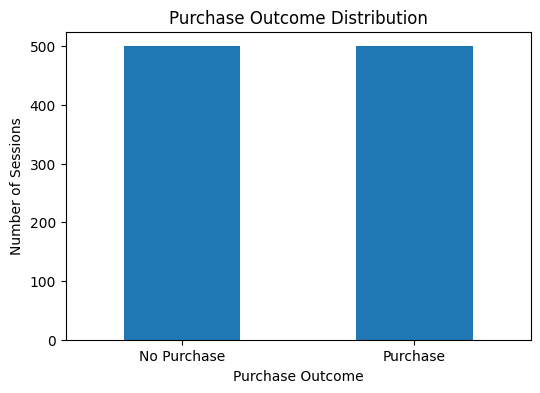

In [11]:
plt.figure(figsize=(6, 4))

df["target"].value_counts().sort_index().plot(
    kind="bar"
)
plt.title("Purchase Outcome Distribution")
plt.xlabel("Purchase Outcome")
plt.ylabel("Number of Sessions")
plt.xticks(
    [0, 1],
    ["No Purchase", "Purchase"],
    rotation=0
)
plt.show()

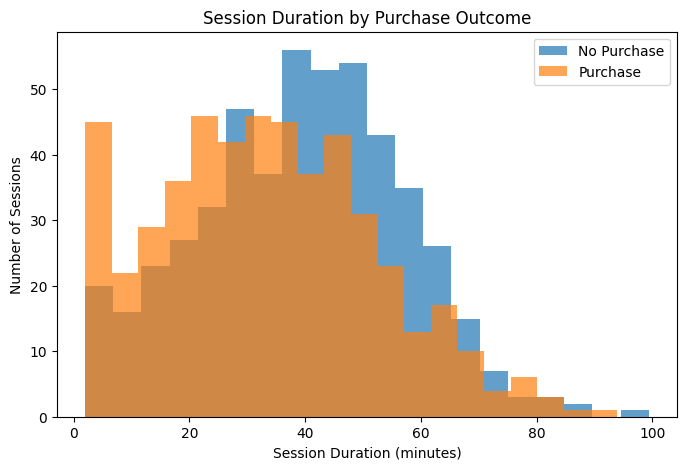

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[df["target"] == 0, "session_minutes"],
    bins=20,
    alpha=0.7,
    label="No Purchase"
)
plt.hist(
    df.loc[df["target"] == 1, "session_minutes"],
    bins=20,
    alpha=0.7,
    label="Purchase"
)
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Number of Sessions")
plt.title("Session Duration by Purchase Outcome")
plt.legend()
plt.show()

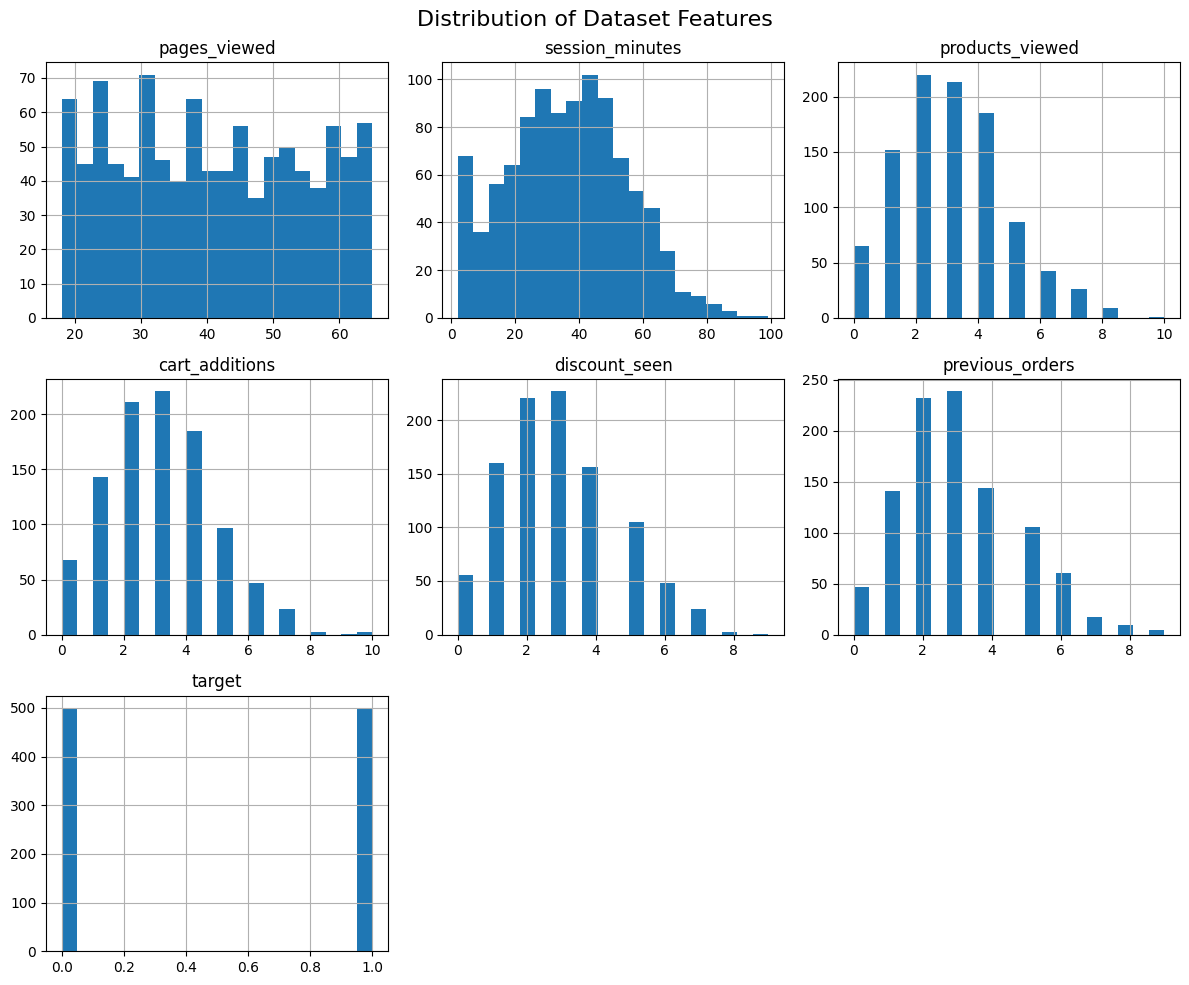

In [13]:
df.hist(
    figsize=(12, 10),
    bins=20
)
plt.suptitle(
    "Distribution of Dataset Features",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [14]:
correlation_matrix = df.corr()
correlation_matrix

,pages_viewed,session_minutes,products_viewed,cart_additions,discount_seen,previous_orders,target
pages_viewed,1.000000,-0.054776,0.026461,-0.005761,0.003970,0.052275,0.258040
session_minutes,-0.054776,1.000000,-0.063549,0.034904,-0.008142,-0.009092,-0.159505
products_viewed,0.026461,-0.063549,1.000000,0.040490,0.010346,-0.060928,0.242168
cart_additions,-0.005761,0.034904,0.040490,1.000000,-0.031567,0.047594,-0.154564
discount_seen,0.003970,-0.008142,0.010346,-0.031567,1.000000,-0.047944,0.264272
previous_orders,0.052275,-0.009092,-0.060928,0.047594,-0.047944,1.000000,-0.167336
target,0.258040,-0.159505,0.242168,-0.154564,0.264272,-0.167336,1.000000


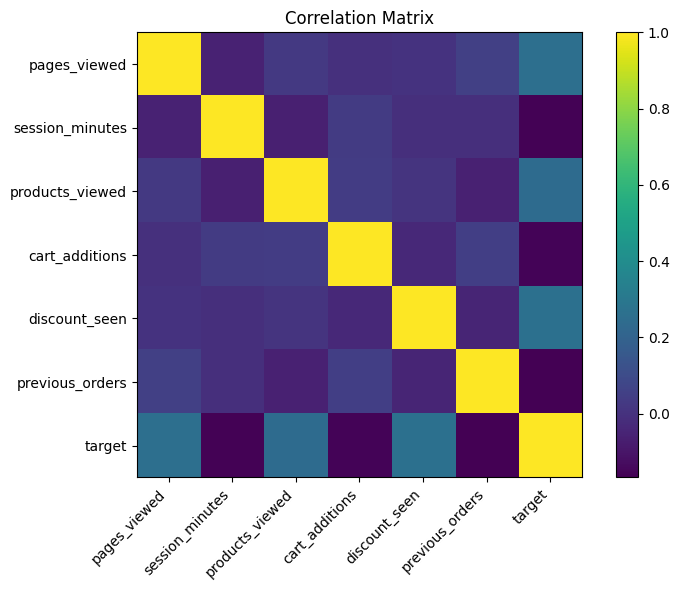

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(
    correlation_matrix,
    interpolation="nearest"
)
plt.colorbar()
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [16]:
X = df.drop(columns=["target"])

y = df["target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("target")

Features:
['pages_viewed', 'session_minutes', 'products_viewed', 'cart_additions', 'discount_seen', 'previous_orders']

Target:
target


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (800, 6)
Testing data shape: (200, 6)


In [18]:
model = Pipeline([
    
    
    ("scaler", StandardScaler()),
    
   
    ("logreg", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])
model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [19]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("Predicted Classes:")
print(y_pred[:20])
print("\nPredicted Purchase Probabilities:")
print(y_prob[:20])

Predicted Classes:
[1 0 0 0 1 1 1 0 0 0 0 1 1 0 1 1 1 0 1 1]

Predicted Purchase Probabilities:
[0.84170707 0.26065758 0.07417713 0.34141529 0.9207025  0.87598293
 0.50986282 0.38070882 0.38261621 0.11578661 0.29282047 0.76145734
 0.71722185 0.10393527 0.53043074 0.58799867 0.87674229 0.20332594
 0.51564248 0.55786965]


In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.73
Accuracy Percentage: 73.0 %


In [21]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)

Precision: 0.7395833333333334


In [22]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)

Recall: 0.71


In [23]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)

F1 Score: 0.7244897959183674


In [24]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8005


In [25]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})
results

,Metric,Score
0,Accuracy,0.730000
1,Precision,0.739583
2,Recall,0.710000
3,F1 Score,0.724490
4,ROC-AUC,0.800500


In [26]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Purchase",
            "Purchase"
        ]
    )
)

              precision    recall  f1-score   support

 No Purchase       0.72      0.75      0.74       100
    Purchase       0.74      0.71      0.72       100

    accuracy                           0.73       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.73      0.73      0.73       200



In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[75 25]
 [29 71]]


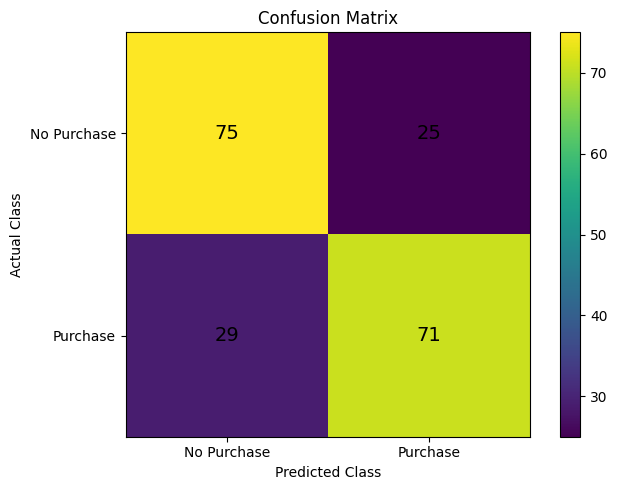

In [28]:
plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(
    [0, 1],
    ["No Purchase", "Purchase"]
)
plt.yticks(
    [0, 1],
    ["No Purchase", "Purchase"]
)
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )
plt.colorbar()
plt.tight_layout()
plt.show()

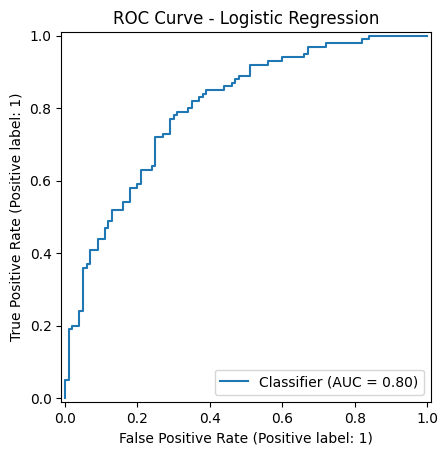

In [29]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [30]:
coefficients = model.named_steps["logreg"].coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

coefficient_table

,Feature,Coefficient
0,pages_viewed,0.636711
1,session_minutes,-0.336610
2,products_viewed,0.612081
3,cart_additions,-0.341428
4,discount_seen,0.652460
5,previous_orders,-0.394278


In [31]:
coefficient_table["Odds Ratio"] = np.exp(
    coefficient_table["Coefficient"]
)

coefficient_table = coefficient_table.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_table

,Feature,Coefficient,Odds Ratio
4,discount_seen,0.652460,1.920259
0,pages_viewed,0.636711,1.890253
2,products_viewed,0.612081,1.844266
1,session_minutes,-0.336610,0.714187
3,cart_additions,-0.341428,0.710755
5,previous_orders,-0.394278,0.674166


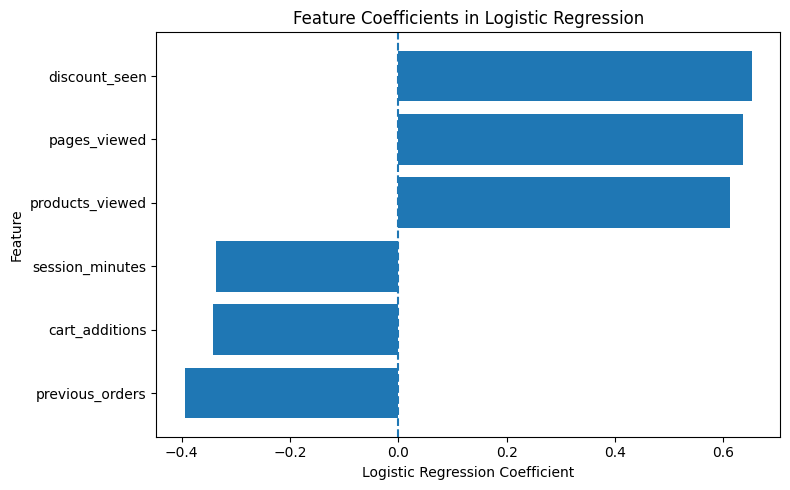

In [32]:
plot_data = coefficient_table.sort_values(
    by="Coefficient"
)
plt.figure(figsize=(8, 5))
plt.barh(
    plot_data["Feature"],
    plot_data["Coefficient"]
)
plt.axvline(
    x=0,
    linestyle="--"
)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title(
    "Feature Coefficients in Logistic Regression"
)
plt.tight_layout()
plt.show()

In [33]:
most_positive = coefficient_table.iloc[0]
most_negative = coefficient_table.iloc[-1]
print(
    "Most positive feature:",
    most_positive["Feature"]
)
print(
    "Coefficient:",
    most_positive["Coefficient"]
)
print()
print(
    "Most negative feature:",
    most_negative["Feature"]
)
print(
    "Coefficient:",
    most_negative["Coefficient"]
)

Most positive feature: discount_seen
Coefficient: 0.6524599601838919

Most negative feature: previous_orders
Coefficient: -0.3942783301931753


In [34]:
final_results = pd.DataFrame({
    "Performance Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    
    "Value": [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(roc_auc, 4)
    ]
})

final_results

,Performance Metric,Value
0,Accuracy,0.7300
1,Precision,0.7396
2,Recall,0.7100
3,F1 Score,0.7245
4,ROC-AUC,0.8005


In [35]:
print("=" * 50)
print("E-COMMERCE PURCHASE INTENT PREDICTION")
print("LOGISTIC REGRESSION")
print("=" * 50)

print(f"Dataset Size       : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Training Samples   : {X_train.shape[0]}")
print(f"Testing Samples    : {X_test.shape[0]}")

print("\nMODEL PERFORMANCE")
print("-" * 50)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")

print("\nCONFUSION MATRIX")
print("-" * 50)
print(cm)

print("\nProject completed successfully!")

E-COMMERCE PURCHASE INTENT PREDICTION
LOGISTIC REGRESSION
Dataset Size       : 1000 rows, 7 columns
Training Samples   : 800
Testing Samples    : 200

MODEL PERFORMANCE
--------------------------------------------------
Accuracy           : 0.7300
Precision          : 0.7396
Recall             : 0.7100
F1 Score           : 0.7245
ROC-AUC            : 0.8005

CONFUSION MATRIX
--------------------------------------------------
[[75 25]
 [29 71]]

Project completed successfully!
